In [2]:
# Martin Konečnik, https://git.siwim.si/machine-learning/fix-qa-binary-classification
# Notebook intended for prototyping binary classification models
import pickle
import random
import tomllib
from pathlib import Path
from typing import List, Tuple

import numpy as np
import torch
from sklearn.model_selection import train_test_split
from swm import factory
from torch.utils.data import DataLoader, TensorDataset

# Initialize CUDA.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
# Set seeds
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [14]:
# Read the configuration file.
with open('conf.toml', 'rb') as f:
    conf = tomllib.load(f)

EVENTS_PATH = Path().home() / conf['data_dir'] / 'prepared'
FIRST_CHANNEL = conf['first_channel']
LAST_CHANNEL = conf['last_channel']
LOAD_EVENTS = conf.get('load_events', False)
EPOCHS = conf['epoch']
LR = conf['lr']
BATCH = conf['batch']
SEEDS = conf['seeds']
LOAD_MODEL = conf.get('model', None)  # None means that a new model is trained

In [5]:
# TODO Feels like signals_unaltered and signals_corrected should be np arrays, but cba changing that now.
unaltered_pkl_path = EVENTS_PATH / 'unaltered.pkl'
corrected_pkl_path = EVENTS_PATH / 'corrected.pkl'
if LOAD_EVENTS or not unaltered_pkl_path.exists() or not corrected_pkl_path.exists():  # To save time event files are only read if pkl files don't exist or if explicitly set in the toml file.
    # Read the event files.
    signals_unaltered = [[] for _ in range(FIRST_CHANNEL, LAST_CHANNEL + 1)]  # Initializes an empty list for each channel.
    signals_corrected = [[] for _ in range(FIRST_CHANNEL, LAST_CHANNEL + 1)]
    binary_labels = []
    for event in (EVENTS_PATH / 'unaltered' / '0').iterdir():
        data = factory.read_file(event)
        for ch in range(FIRST_CHANNEL, LAST_CHANNEL + 1):
            signals_unaltered[ch].append(data.acqdata.a[ch].data)
    with open(unaltered_pkl_path, 'wb') as f:
        pickle.dump(signals_unaltered, f)

    for event in (EVENTS_PATH / 'corrected' / '0').iterdir():
        data = factory.read_file(event)
        for ch in range(FIRST_CHANNEL, LAST_CHANNEL + 1):
            signals_corrected[ch].append(data.acqdata.a[ch].data)
    with open(corrected_pkl_path, 'wb') as f:
        pickle.dump(signals_corrected, f)
else:
    # Read the pickled arrays.
    with open(unaltered_pkl_path, 'rb') as f:
        signals_unaltered = pickle.load(f)
    with open(corrected_pkl_path, 'rb') as f:
        signals_corrected = pickle.load(f)

In [6]:
print(f'Number of channels: {len(signals_unaltered)}.')
print(f'Unaltered signals: {len(signals_unaltered[0])}.')
print(f'Corrected signals: {len(signals_corrected[0])}.')

Number of channels: 8.
Unaltered signals: 60309.
Corrected signals: 1192.


In [7]:
def splice(my_list: List[float], index: int, signal_length: int) -> Tuple[np.array, np.array]:
    """
    Split signals into two arrays.
    :param my_list: List of signals to be processed.
    :param index: Index on which the lists are split.
    :param signal_length: Maximum length of a signal.
    :return:
    """
    result = [[] for _ in range(len(my_list))]
    print(f'Processing {len(my_list)} channels ...')
    for i, veh in enumerate(my_list):
        print(f'Processing {len(veh)} signals for channel {i} ...')
        for signal in veh:  # Normalize the signals.
            result[i].append(np.pad(signal - signal[0], (0, signal_length - len(signal)), mode='edge'))
    return np.array([sublist[:index] for sublist in result]), np.array([sublist[index:] for sublist in result])


# Split signals into training and testing sets.
num_signals = len(signals_unaltered)
max_length = max(len(signal) for signal in signals_unaltered[0] + signals_corrected[0])

signals_unaltered, test_unaltered = splice(signals_unaltered, -200, max_length)
signals_corrected, test_corrected = splice(signals_corrected, -100, max_length)

Processing 8 channels ...
Processing 60309 signals for channel 0 ...
Processing 60309 signals for channel 1 ...
Processing 60309 signals for channel 2 ...
Processing 60309 signals for channel 3 ...
Processing 60309 signals for channel 4 ...
Processing 60309 signals for channel 5 ...
Processing 60309 signals for channel 6 ...
Processing 60309 signals for channel 7 ...
Processing 8 channels ...
Processing 1192 signals for channel 0 ...
Processing 1192 signals for channel 1 ...
Processing 1192 signals for channel 2 ...
Processing 1192 signals for channel 3 ...
Processing 1192 signals for channel 4 ...
Processing 1192 signals for channel 5 ...
Processing 1192 signals for channel 6 ...
Processing 1192 signals for channel 7 ...


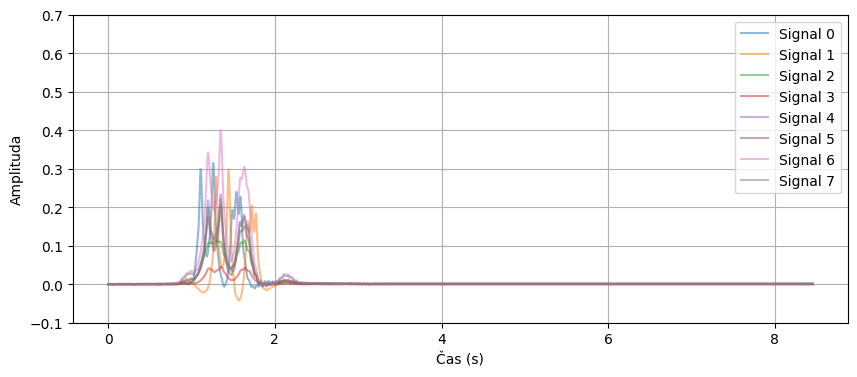

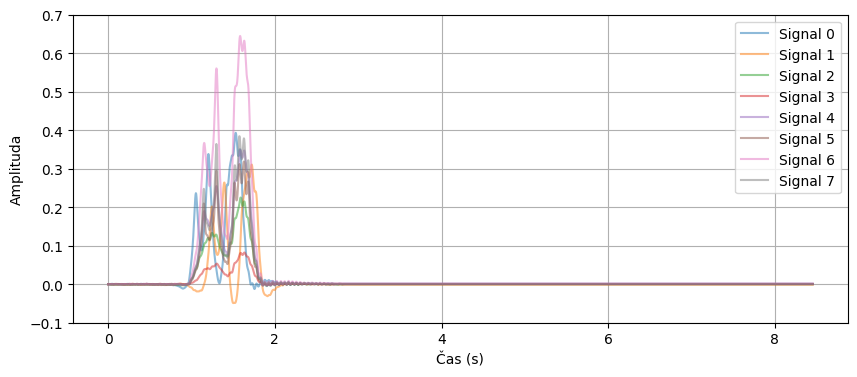

In [8]:
# Sample signal
import matplotlib.pyplot as plt

if not LOAD_MODEL:
    plt.figure(figsize=(10, 4))
    for i in range(num_signals):
        plt.plot(np.arange(max_length) / 512, signals_unaltered[i][0], label=f'Signal {i}', alpha=0.5)
    plt.xlabel('Čas (s)')
    plt.ylabel('Amplituda')
    plt.ylim(-0.1, 0.7)
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    for i in range(num_signals):
        plt.plot(np.arange(max_length) / 512, signals_corrected[i][2], label=f'Signal {i}', alpha=0.5)
    plt.xlabel('Čas (s)')
    plt.ylabel('Amplituda')
    plt.ylim(-0.1, 0.7)
    plt.grid(True)
    plt.legend()
    plt.show()

In [9]:
# Average out all the signals
if not LOAD_MODEL:
    # Generate additional corrected signals bi removing channels.
    # avg_all = np.mean(signals_corrected, axis=0)
    # avg_no_ch1 = np.mean(signals_corrected[1:, :, :], axis=0)  # Remove channel 1
    # avg_no_ch8 = np.mean(signals_corrected[:-1, :, :], axis=0)  # Remove channel 8
    #
    # # Concatenate (now we can reassign)
    # signals_corrected = np.concatenate([avg_all, avg_no_ch1, avg_no_ch8], axis=0)
    signals_corrected = np.mean(signals_corrected, axis=0)

    # We have enough of unaltered signals to train on.
    signals_unaltered = np.mean(signals_unaltered, axis=0)

In [10]:
if not LOAD_MODEL:
    num_samples = len(signals_corrected)  # This value represents the number of samples for each class.
    print(f'Number of signals: {num_signals}.')
    print(f'Max length: {max_length}.')
    print(f'Number of samples: {num_samples}.')

    print(f'Corrected shape: {signals_corrected.shape}')
    print(f'Unaltered shape: {signals_unaltered.shape}')

Number of signals: 8.
Max length: 4329.
Number of samples: 1092.
Corrected shape: (1092, 4329)
Unaltered shape: (60109, 4329)


In [18]:
from sklearn.metrics import fbeta_score, precision_score, recall_score
from classifier import BinaryClassifier

MODEL = 'classifier'

torch.cuda.empty_cache()

if not LOAD_MODEL:
    results = {}

    # Train the model with different seeds.
    for seed in SEEDS:
        print(f'Running for seed: {seed}')
        results[seed] = {}
        set_seed(seed)

        total_available = len(signals_unaltered[0])
        unaltered = random.sample(range(total_available), num_samples * 2)  # Add double number of samples for unaltered class
        signals = np.vstack((np.empty((num_samples * 2, max_length)), signals_corrected))  # Create numpy array with empty space for unaltered signals

        for i, sample in enumerate(unaltered):  # Add unaltered signals to the array.
            signals[i] = signals_unaltered[sample]

        binary_labels = np.array([0] * num_samples * 2 + [1] * num_samples)

        # Split indices into train/validation
        train_idx, val_idx = train_test_split(
            np.arange(len(signals)),  # Split the indices
            test_size=0.2,
            random_state=seed  # Always set random state for reproducibility
        )

        X_tensor = torch.from_numpy(signals).unsqueeze(1).to(device)  # Unsqueeze is done to ensure tensor dimensions are correct for conv1d to work properly.
        y_tensor = torch.from_numpy(binary_labels).to(device)

        # Create dataset
        full_dataset = TensorDataset(X_tensor, y_tensor)
        # Create train/test datasets using the indices we split earlier
        train_dataset = torch.utils.data.Subset(full_dataset, train_idx)
        val_dataset = torch.utils.data.Subset(full_dataset, val_idx)

        torch.multiprocessing.set_start_method('spawn', force=True)

        for batch_size in BATCH:
            print(f'With batch size: {batch_size}')
            results[seed][batch_size] = {}
            # Prepare DataLoaders
            train_loader = DataLoader(
                train_dataset,
                batch_size=batch_size,
                shuffle=True,
                generator=torch.Generator().manual_seed(seed)
            )
            val_loader = DataLoader(
                val_dataset,
                batch_size=batch_size
            )

            for lr in LR:
                print(f'With LR: {lr}')
                results[seed][batch_size][lr] = {}

                for num_epochs in EPOCHS:
                    print(f'With epoch: {num_epochs}')
                    results[seed][batch_size][lr][num_epochs] = {
                        'train_loss': [],
                        'val_loss': []
                    }
                    model = BinaryClassifier(max_length).to(device)
                    criterion = torch.nn.BCEWithLogitsLoss()  # Binary Cross Entropy Loss
                    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
                    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)

                    for epoch in range(num_epochs):
                        model.train()
                        running_loss = 0.0

                        for inputs, labels in train_loader:
                            optimizer.zero_grad()
                            outputs = model(inputs.float()).squeeze()
                            loss = criterion(outputs, labels.float())
                            loss.backward()
                            optimizer.step()
                            running_loss += loss.item()

                        results[seed][batch_size][lr][num_epochs]['train_loss'].append(running_loss / len(train_loader))

                        model.eval()
                        val_running_loss = 0.0

                        with torch.no_grad():
                            for inputs, labels in val_loader:
                                outputs = model(inputs.float()).squeeze()
                                loss = criterion(outputs, labels.float())
                                val_running_loss += loss.item()

                        results[seed][batch_size][lr][num_epochs]['val_loss'].append(val_running_loss / len(val_loader))

                    # Final loss
                    print(f'Epoch {epoch + 1}, Train Loss: {results[seed][batch_size][lr][num_epochs]['train_loss'][-1]:.4f}, Val Loss: {results[seed][batch_size][lr][num_epochs]['val_loss'][-1]:.4f}')

                    model.eval()
                    with torch.no_grad():
                        correct = 0
                        total = 0
                        all_preds = []
                        all_labels = []

                        for inputs, labels in val_loader:
                            outputs = model(inputs.float())
                            predicted = (outputs > 0.5).float()
                            all_preds.extend(predicted.squeeze().cpu().numpy())
                            all_labels.extend(labels.cpu().numpy())
                            total += labels.size(0)
                            correct += (predicted.squeeze() == labels).sum().item()

                        # Metrics
                        acc = 100 * correct / total
                        precision = precision_score(all_labels, all_preds, zero_division=0)
                        recall = recall_score(all_labels, all_preds, zero_division=0)
                        f2 = fbeta_score(all_labels, all_preds, beta=2, zero_division=0)
                        f3 = fbeta_score(all_labels, all_preds, beta=3, zero_division=0)

                        print(f'Accuracy: {acc:.2f}%')
                        print(f'Precision: {precision:.4f}')
                        print(f'Recall: {recall:.4f}')
                        print(f'F2: {f2:.4f}')
                        print(f'F3: {f3:.4f}')

                        results[seed][batch_size][lr][num_epochs]['accuracy'] = acc
                        results[seed][batch_size][lr][num_epochs]['precision'] = precision
                        results[seed][batch_size][lr][num_epochs]['recall'] = recall
                        results[seed][batch_size][lr][num_epochs]['f2'] = f2
                        results[seed][batch_size][lr][num_epochs]['f3'] = f3
                    torch.cuda.empty_cache()

Running for seed: 1
With batch size: 16
With LR: 0.0001
With epoch: 50
Epoch 50, Train Loss: 0.3450, Val Loss: 0.5010
Accuracy: 74.24%
Precision: 0.9412
Recall: 0.2243
F2: 0.2646
F3: 0.2428
Running for seed: 2
With batch size: 16
With LR: 0.0001
With epoch: 50
Epoch 50, Train Loss: 0.3494, Val Loss: 0.3374
Accuracy: 82.77%
Precision: 0.9149
Recall: 0.5609
F2: 0.6079
F3: 0.5834
Running for seed: 3
With batch size: 16
With LR: 0.0001
With epoch: 50
Epoch 50, Train Loss: 0.3565, Val Loss: 0.3523
Accuracy: 84.76%
Precision: 0.8588
Recall: 0.6577
F2: 0.6900
F3: 0.6734
Running for seed: 4
With batch size: 16
With LR: 0.0001
With epoch: 50
Epoch 50, Train Loss: 0.3498, Val Loss: 0.3153
Accuracy: 86.43%
Precision: 0.9020
Recall: 0.6509
F2: 0.6893
F3: 0.6696
Running for seed: 5
With batch size: 16
With LR: 0.0001
With epoch: 50
Epoch 50, Train Loss: 0.4366, Val Loss: 0.4779
Accuracy: 75.46%
Precision: 0.7752
Recall: 0.4310
F2: 0.4730
F3: 0.4511
Running for seed: 6
With batch size: 16
With LR: 0

In [25]:
# Average metrics
print("\n" + "=" * 80)
print("Averages after all iterations")
print("=" * 80)

for batch_size in BATCH:
    for lr in LR:
        for num_epochs in EPOCHS:
            accuracies = []
            precisions = []
            recalls = []
            f2_scores = []
            f3_scores = []
            final_train_losses = []
            final_val_losses = []

            for seed in results:
                metrics = results[seed][batch_size][lr][num_epochs]

                accuracies.append(metrics.get('accuracy', 0))
                precisions.append(metrics.get('precision', 0))
                recalls.append(metrics.get('recall', 0))
                f2_scores.append(metrics.get('f2', 0))
                f3_scores.append(metrics.get('f3', 0))

                # Končni loss (zadnja epoha)
                train_loss = metrics.get('train_loss', [])
                val_loss = metrics.get('val_loss', [])
                if train_loss:
                    final_train_losses.append(train_loss[-1])
                if val_loss:
                    final_val_losses.append(val_loss[-1])

        # Izračun povprečij in standardnih odklonov
        mean_acc = np.mean(accuracies)
        std_acc = np.std(accuracies)
        mean_prec = np.mean(precisions)
        std_prec = np.std(precisions)
        mean_recall = np.mean(recalls)
        std_recall = np.std(recalls)
        mean_f2 = np.mean(f2_scores)
        std_f2 = np.std(f2_scores)
        mean_f3 = np.mean(f3_scores)
        std_f3 = np.std(f3_scores)
        mean_train_loss = np.mean(final_train_losses)
        std_train_loss = np.std(final_train_losses)
        mean_val_loss = np.mean(final_val_losses)
        std_val_loss = np.std(final_val_losses)

        print(f"\n📊 BS={batch_size}, LR={lr}, Epochs={num_epochs}")
        print(f"   Accuracy: {mean_acc:.2f}% ± {std_acc:.2f}%")
        print(f"   Precision: {mean_prec:.4f} ± {std_prec:.4f}")
        print(f"   Recall: {mean_recall:.4f} ± {std_recall:.4f}")
        print(f"   F2: {mean_f2:.4f} ± {std_f2:.4f}")
        print(f"   F3: {mean_f3:.4f} ± {std_f3:.4f}")
        print(f"   Train Loss: {mean_train_loss:.4f} ± {std_train_loss:.4f}")
        print(f"   Val Loss: {mean_val_loss:.4f} ± {std_val_loss:.4f}")


POVPREČNI REZULTATI PO VSEH ITERACIJAH

📊 BS=16, LR=0.0001, Epochs=50
   Accuracy: 81.19% ± 5.39%
   Precision: 0.8731 ± 0.0655
   Recall: 0.5417 ± 0.1887
   F2: 0.5754 ± 0.1812
   F3: 0.5578 ± 0.1854
   Train Loss: 0.3546 ± 0.0280
   Val Loss: 0.3958 ± 0.0883

📊 BS=16, LR=0.0001, Epochs=50
   Accuracy: 81.19% ± 5.39%
   Precision: 0.8731 ± 0.0655
   Recall: 0.5417 ± 0.1887
   F2: 0.5754 ± 0.1812
   F3: 0.5578 ± 0.1854
   Train Loss: 0.3546 ± 0.0280
   Val Loss: 0.3958 ± 0.0883

📊 BS=16, LR=0.0001, Epochs=50
   Accuracy: 81.19% ± 5.39%
   Precision: 0.8731 ± 0.0655
   Recall: 0.5417 ± 0.1887
   F2: 0.5754 ± 0.1812
   F3: 0.5578 ± 0.1854
   Train Loss: 0.3546 ± 0.0280
   Val Loss: 0.3958 ± 0.0883

📊 BS=16, LR=0.0001, Epochs=50
   Accuracy: 81.19% ± 5.39%
   Precision: 0.8731 ± 0.0655
   Recall: 0.5417 ± 0.1887
   F2: 0.5754 ± 0.1812
   F3: 0.5578 ± 0.1854
   Train Loss: 0.3546 ± 0.0280
   Val Loss: 0.3958 ± 0.0883

📊 BS=16, LR=0.0001, Epochs=50
   Accuracy: 81.19% ± 5.39%
   Precision:

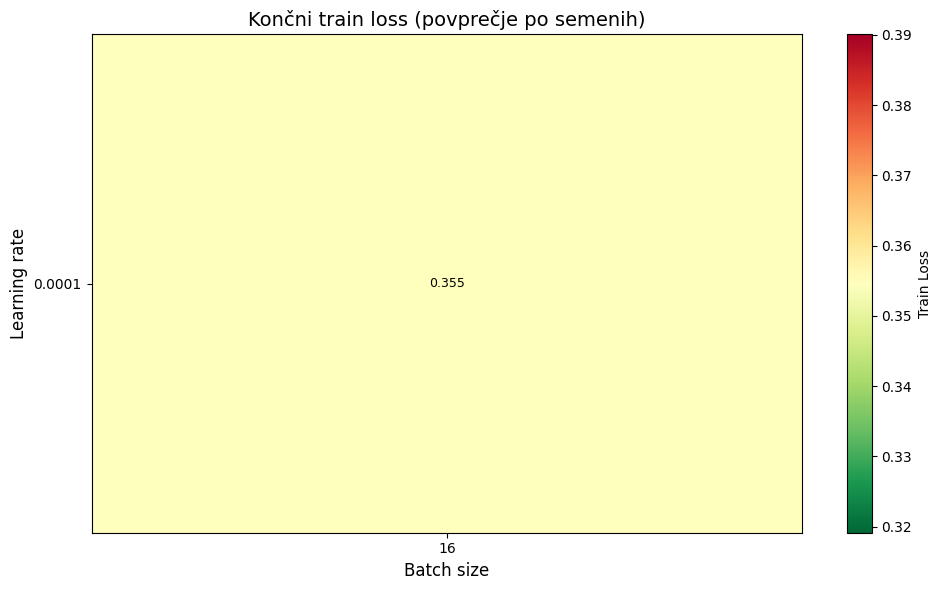

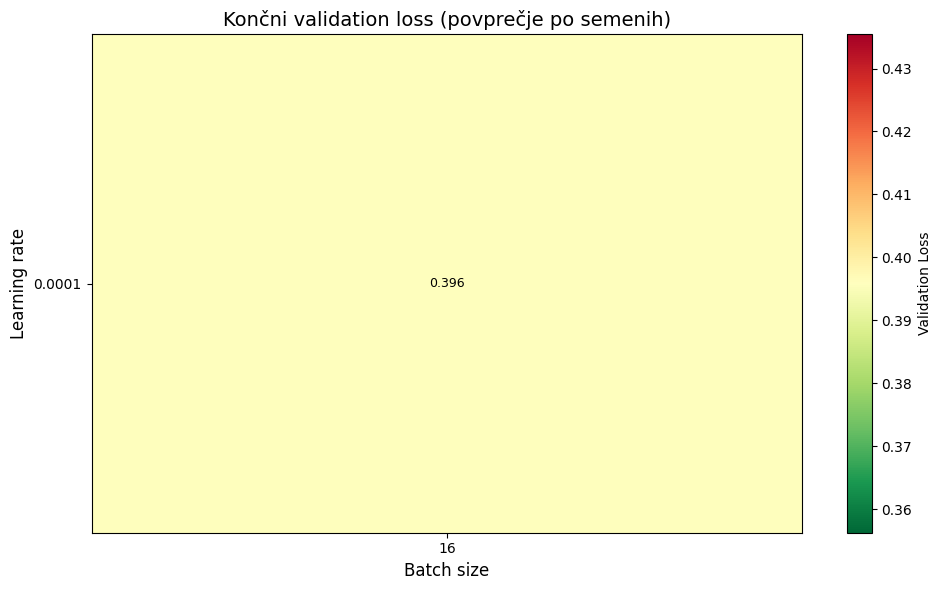

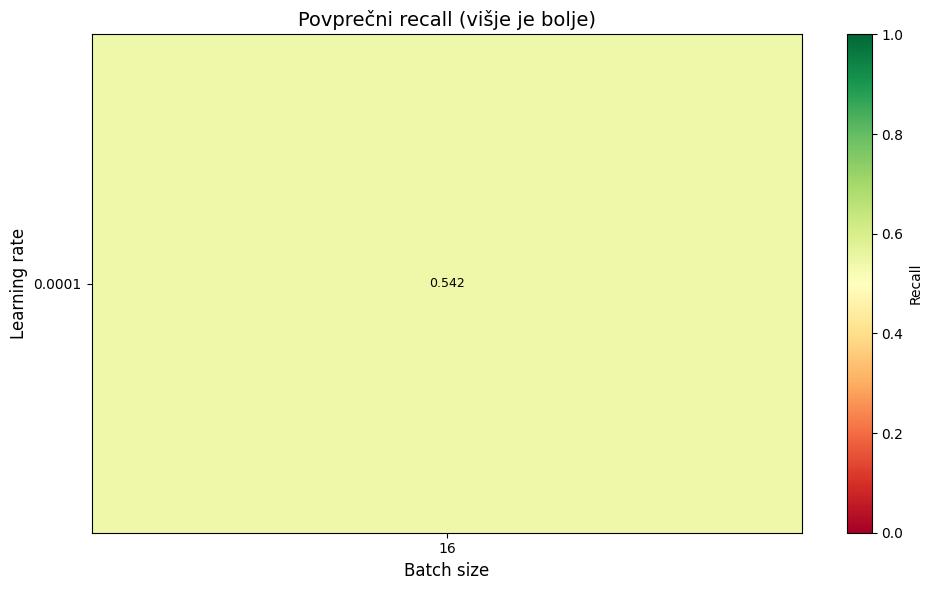


TABELA REZULTATOV ZA VSE KOMBINACIJE HIPERPARAMETROV
    LR  Batch    Train Loss      Val Loss        Recall            F2    Accuracy
0.0001     16 0.355 ± 0.028 0.396 ± 0.088 0.542 ± 0.189 0.575 ± 0.181 81.2 ± 5.4%

NAJBOLJŠE KOMBINACIJE PO POSAMEZNIH METRIKAH

🏆 Najboljši recall: 0.542 ± 0.189
   LR=0.0001, Batch=16

🏆 Najboljši F2: 0.575 ± 0.181
   LR=0.0001, Batch=16

🏆 Najnižji val loss: 0.396 ± 0.088
   LR=0.0001, Batch=16

✅ Rezultati shranjeni v 'hyperparameter_results.csv'


In [26]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# ZBIRANJE PODATKOV IZ results SLOVARJA
# ============================================================

# Predpostavljena struktura:
# results[seed][batch_size][lr][num_epochs] = {
#     'train_loss': [list of losses per epoch],
#     'val_loss': [list of losses per epoch],
#     'accuracy': acc,
#     'recall': recall,
#     'f2': f2,
#     'f3': f3
# }

# Zbiranje vseh kombinacij
learning_rates = sorted(set([lr for seed in results for bs in results[seed] for lr in results[seed][bs]]))
batch_sizes = sorted(set([bs for seed in results for bs in results[seed]]))
epochs_list = sorted(set([ep for seed in results for bs in results[seed] for lr in results[seed][bs] for ep in results[seed][bs][lr]]))

# Matrike za povprečne vrednosti
train_loss_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
val_loss_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
train_loss_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
val_loss_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))

# Matrike za metrike
recall_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
recall_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
f2_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
f2_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
accuracy_matrix = np.zeros((len(learning_rates), len(batch_sizes)))
accuracy_std_matrix = np.zeros((len(learning_rates), len(batch_sizes)))

for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        train_losses = []
        val_losses = []
        recalls = []
        f2_scores = []
        accuracies = []

        for seed in results:
            if bs in results[seed] and lr in results[seed][bs]:
                for num_epochs in results[seed][bs][lr]:
                    data = results[seed][bs][lr][num_epochs]

                    # Končni loss (zadnja epoha)
                    train_loss = data['train_loss']
                    val_loss = data['val_loss']
                    if isinstance(train_loss, list):
                        train_loss = train_loss[-1]
                    if isinstance(val_loss, list):
                        val_loss = val_loss[-1]

                    train_losses.append(train_loss)
                    val_losses.append(val_loss)
                    recalls.append(data.get('recall', 0))
                    f2_scores.append(data.get('f2', 0))
                    accuracies.append(data.get('accuracy', 0))

        # Povprečja in standardni odkloni
        if train_losses:
            train_loss_matrix[i, j] = np.mean(train_losses)
            train_loss_std_matrix[i, j] = np.std(train_losses)
            val_loss_matrix[i, j] = np.mean(val_losses)
            val_loss_std_matrix[i, j] = np.std(val_losses)
            recall_matrix[i, j] = np.mean(recalls)
            recall_std_matrix[i, j] = np.std(recalls)
            f2_matrix[i, j] = np.mean(f2_scores)
            f2_std_matrix[i, j] = np.std(f2_scores)
            accuracy_matrix[i, j] = np.mean(accuracies)
            accuracy_std_matrix[i, j] = np.std(accuracies)

# ============================================================
# HEATMAP 1: Končni train loss
# ============================================================
fig1, ax1 = plt.subplots(figsize=(10, 6))
im1 = ax1.imshow(train_loss_matrix, cmap='RdYlGn_r', aspect='auto')

ax1.set_xticks(np.arange(len(batch_sizes)))
ax1.set_yticks(np.arange(len(learning_rates)))
ax1.set_xticklabels(batch_sizes)
ax1.set_yticklabels([f'{lr:.4f}' for lr in learning_rates])

ax1.set_xlabel('Batch size', fontsize=12)
ax1.set_ylabel('Learning rate', fontsize=12)
ax1.set_title('Končni train loss (povprečje po semenih)', fontsize=14)

cbar1 = plt.colorbar(im1, ax=ax1, label='Train Loss')

# Številke v celicah
for i in range(len(learning_rates)):
    for j in range(len(batch_sizes)):
        if not np.isnan(train_loss_matrix[i, j]):
            ax1.text(j, i, f'{train_loss_matrix[i, j]:.3f}',
                     ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# HEATMAP 2: Končni validation loss
# ============================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))
im2 = ax2.imshow(val_loss_matrix, cmap='RdYlGn_r', aspect='auto')

ax2.set_xticks(np.arange(len(batch_sizes)))
ax2.set_yticks(np.arange(len(learning_rates)))
ax2.set_xticklabels(batch_sizes)
ax2.set_yticklabels([f'{lr:.4f}' for lr in learning_rates])

ax2.set_xlabel('Batch size', fontsize=12)
ax2.set_ylabel('Learning rate', fontsize=12)
ax2.set_title('Končni validation loss (povprečje po semenih)', fontsize=14)

cbar2 = plt.colorbar(im2, ax=ax2, label='Validation Loss')

for i in range(len(learning_rates)):
    for j in range(len(batch_sizes)):
        if not np.isnan(val_loss_matrix[i, j]):
            ax2.text(j, i, f'{val_loss_matrix[i, j]:.3f}',
                     ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# HEATMAP 3: Recall (skupaj)
# ============================================================
fig3, ax3 = plt.subplots(figsize=(10, 6))
im3 = ax3.imshow(recall_matrix, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)

ax3.set_xticks(np.arange(len(batch_sizes)))
ax3.set_yticks(np.arange(len(learning_rates)))
ax3.set_xticklabels(batch_sizes)
ax3.set_yticklabels([f'{lr:.4f}' for lr in learning_rates])

ax3.set_xlabel('Batch size', fontsize=12)
ax3.set_ylabel('Learning rate', fontsize=12)
ax3.set_title('Povprečni recall (višje je bolje)', fontsize=14)

cbar3 = plt.colorbar(im3, ax=ax3, label='Recall')

for i in range(len(learning_rates)):
    for j in range(len(batch_sizes)):
        if not np.isnan(recall_matrix[i, j]):
            ax3.text(j, i, f'{recall_matrix[i, j]:.3f}',
                     ha="center", va="center", fontsize=9)

plt.tight_layout()
plt.show()

# ============================================================
# TABELA Z VSEMI REZULTATI
# ============================================================
print("\n" + "=" * 120)
print("TABELA REZULTATOV ZA VSE KOMBINACIJE HIPERPARAMETROV")
print("=" * 120)

# Ustvari podatke za pandas DataFrame
table_data = []
for i, lr in enumerate(learning_rates):
    for j, bs in enumerate(batch_sizes):
        if not np.isnan(train_loss_matrix[i, j]):
            table_data.append({
                'LR': lr,
                'Batch': bs,
                'Učna izguba': f"{train_loss_matrix[i, j]:.3f} ± {train_loss_std_matrix[i, j]:.3f}",
                'Validacijska izguba': f"{val_loss_matrix[i, j]:.3f} ± {val_loss_std_matrix[i, j]:.3f}",
                'Recall': f"{recall_matrix[i, j]:.3f} ± {recall_std_matrix[i, j]:.3f}",
                'F2': f"{f2_matrix[i, j]:.3f} ± {f2_std_matrix[i, j]:.3f}",
                'Accuracy': f"{accuracy_matrix[i, j]:.1f} ± {accuracy_std_matrix[i, j]:.1f}%"
            })

df = pd.DataFrame(table_data)
print(df.to_string(index=False))

# ============================================================
# NAJBOLJŠE KOMBINACIJE
# ============================================================
print("\n" + "=" * 80)
print("NAJBOLJŠE KOMBINACIJE PO POSAMEZNIH METRIKAH")
print("=" * 80)

# Najboljši recall
best_recall_idx = np.unravel_index(np.argmax(recall_matrix), recall_matrix.shape)
print(f"\n🏆 Najboljši recall: {recall_matrix[best_recall_idx]:.3f} ± {recall_std_matrix[best_recall_idx]:.3f}")
print(f"   LR={learning_rates[best_recall_idx[0]]}, Batch={batch_sizes[best_recall_idx[1]]}")

# Najboljši F2
best_f2_idx = np.unravel_index(np.argmax(f2_matrix), f2_matrix.shape)
print(f"\n🏆 Najboljši F2: {f2_matrix[best_f2_idx]:.3f} ± {f2_std_matrix[best_f2_idx]:.3f}")
print(f"   LR={learning_rates[best_f2_idx[0]]}, Batch={batch_sizes[best_f2_idx[1]]}")

# Najnižji val loss
best_val_idx = np.unravel_index(np.argmin(val_loss_matrix), val_loss_matrix.shape)
print(f"\n🏆 Najnižji val loss: {val_loss_matrix[best_val_idx]:.3f} ± {val_loss_std_matrix[best_val_idx]:.3f}")
print(f"   LR={learning_rates[best_val_idx[0]]}, Batch={batch_sizes[best_val_idx[1]]}")

# ============================================================
# SHRAJE VANJE V CSV
# ============================================================
df.to_csv('hyperparameter_results.csv', index=False)
print("\n✅ Rezultati shranjeni v 'hyperparameter_results.csv'")